In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [5]:
import nltk

In [6]:
# import dataset

df=pd.read_csv('spam.csv',encoding='latin-1')

In [7]:
df.head(3)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN


In [8]:
df=df[['v1','v2']]
df.columns=['label','message']

In [9]:
df.head(3)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [10]:
# understand dataset

print(df.shape, '\n')
print(df.info(),'\n')
print(df.describe())

(5572, 2) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None 

       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30


In [12]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [13]:
# data cleaning

df.isnull().sum()

label      0
message    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df.drop_duplicates(inplace=True)

In [17]:
df.shape

(5169, 2)

In [18]:
# convert labels

df['label']=df['label'].map({'ham':0, 'spam':1})
df.head(3)

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...


In [19]:
# text processing

import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [20]:
def preprocess(text):
    text=text.lower()
    words=word_tokenize(text)
    words=[w for w in words if w.isalpha()]
    words=[w for w in words if w not in stopwords.words('english')]
    return " ".join(words)

df['clean_message']=df['message'].apply(preprocess)

In [22]:
df.head(3)

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts may...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


In [23]:
# feature engineering

tfidf=TfidfVectorizer()
x=tfidf.fit_transform(df['clean_message'])
y=df['label']

In [24]:
# split dataset

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2 ,random_state=42)

In [25]:
# model Training

model=MultinomialNB()

model.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3627., 508.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7138)","[[ 0.34, 1.34, 0.08,..., 0.26, 0.41,14.1 ], [ 0. , 0. , 0. ,..., 0. , 0. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7138)","[[-9.38,-8.83,-9.6 ,...,-9.45,-9.33,-6.96], [-9.08,-9.08,-9.08,...,-9.08,-9.08,-9.08]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7138


In [26]:
# prediction

y_pred=model.predict(x_test)

In [27]:
# evaluation

accuracy_score(y_test,y_pred)

0.9642166344294004

In [36]:
cm=confusion_matrix(y_test,y_pred)

In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.74      0.85       145

    accuracy                           0.96      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.96      0.96      1034



Text(0, 0.5, 'actual')

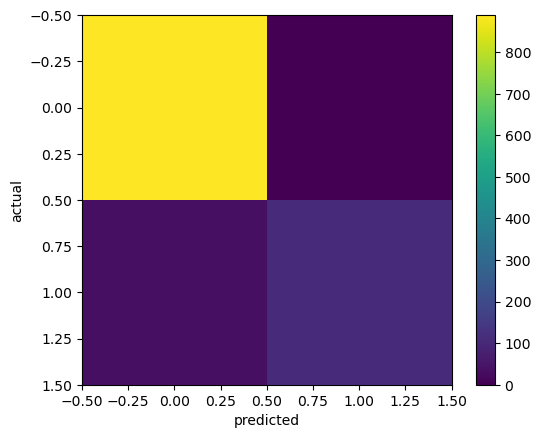

In [39]:
plt.imshow(cm)
plt.colorbar()
plt.xlabel('predicted')
plt.ylabel('actual')

In [41]:
# test new message

msg=['Congratulation! You won a free iphone. click now']
msg=tfidf.transform(msg)
pred=model.predict(msg)
pred

array([0])

In [42]:
if pred[0]==1:
    print('spam')
else:
    print('ham')

ham
